# Block 12 — Ensembles: Multi-Model, Random Forests & Gradient-Boosted Trees
### Advanced Machine Learning — M&T Bank

**Dataset:** `bank_marketing_features.csv` (unchanged since Day 1, Block 3). Same target `y`, same train/test split
(`test_size=0.2, random_state=42, stratify=y`) reused since Block 4. No new CSV comes out of this block.

**The challenger-model question:** Block 6 already has a well-understood, documented benchmark — a regularized
logistic regression at ROC-AUC 0.7958. Two tree ensembles enter today to try to beat it. Neither gets a free pass
for being more complex — each has to earn it.


## Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Paste the raw GitHub URL for bank_marketing_features.csv below, then remove the leading '#':
# df = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";")
feature_cols = [c for c in df.columns if c not in ("education", "y", "duration")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]
X = df[feature_cols].copy()
for c in bool_cols:
    X[c] = X[c].astype(int)
y = df["y"].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(Xtr)} rows. Test: {len(Xte)} rows.")


## 1. The Benchmark to Beat

Reusing Block 6's exact feature-prep pattern (scaled logistic regression) to reconfirm the number we're comparing
everything else against today.


In [2]:
numeric_to_scale = [
    "age", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "education_rank", "month_sin", "month_cos", "campaign_intensity",
    "emp.var.rate_denoised", "cons.price.idx_denoised", "cons.conf.idx_denoised",
    "euribor3m_denoised", "nr.employed_denoised",
]
scaler = StandardScaler()
Xtr_s, Xte_s = Xtr.copy(), Xte.copy()
Xtr_s[numeric_to_scale] = scaler.fit_transform(Xtr[numeric_to_scale])
Xte_s[numeric_to_scale] = scaler.transform(Xte[numeric_to_scale])

lr = LogisticRegression(max_iter=2000, C=0.5)
lr.fit(Xtr_s, ytr)
lr_auc = roc_auc_score(yte, lr.predict_proba(Xte_s)[:, 1])
print(f"Logistic regression benchmark (Block 6): test ROC-AUC = {lr_auc:.4f}")


Logistic regression benchmark (Block 6): test ROC-AUC = 0.7958


## 2. First Challenger: Random Forest, Default Settings

Random forests bag many decision trees, each trained on a bootstrap sample with a random subset of features
considered at each split — the idea is that many high-variance, low-bias trees average out to something more
stable than any one of them.


In [3]:
rf_default = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_default.fit(Xtr, ytr)

rf_train_auc = roc_auc_score(ytr, rf_default.predict_proba(Xtr)[:, 1])
rf_test_auc = roc_auc_score(yte, rf_default.predict_proba(Xte)[:, 1])
print(f"Random Forest (default, unlimited depth): train AUC = {rf_train_auc:.4f}, test AUC = {rf_test_auc:.4f}")
print(f"Compare to logistic benchmark: {lr_auc:.4f}")


Random Forest (default, unlimited depth): train AUC = 0.9998, test AUC = 0.7767
Compare to logistic benchmark: 0.7958


**The default random forest scores *worse* on the test set than the simple logistic regression it was supposed to
beat — 0.775 vs. 0.796 — while fitting the training set almost perfectly (0.9998).** That gap between train and
test AUC (0.225) is a textbook overfitting signature: unlimited-depth trees memorize training-set noise, and
bagging averages many memorized-but-different trees rather than fixing the underlying problem. More complexity, on
its own, bought nothing here — it cost accuracy.


## 3. Does Limiting Depth Fix It?

Random forests have a real regularization knob: `max_depth`. Sweep it and watch the train/test gap.


In [4]:
depth_rows = []
for depth in [3, 6, 10, None]:
    rf_d = RandomForestClassifier(n_estimators=200, max_depth=depth, random_state=42, n_jobs=-1)
    rf_d.fit(Xtr, ytr)
    tr_auc = roc_auc_score(ytr, rf_d.predict_proba(Xtr)[:, 1])
    te_auc = roc_auc_score(yte, rf_d.predict_proba(Xte)[:, 1])
    depth_rows.append({
        "max_depth": depth if depth is not None else "None (unlimited)",
        "Train AUC": round(tr_auc, 4),
        "Test AUC": round(te_auc, 4),
        "Train-Test gap": round(tr_auc - te_auc, 4),
    })
pd.DataFrame(depth_rows)


,max_depth,Train AUC,Test AUC,Train-Test gap
0,3,0.7893,0.7976,-0.0083
1,6,0.8080,0.8104,-0.0024
2,10,0.8594,0.8161,0.0433
3,None (unlimited),0.9998,0.7752,0.2247


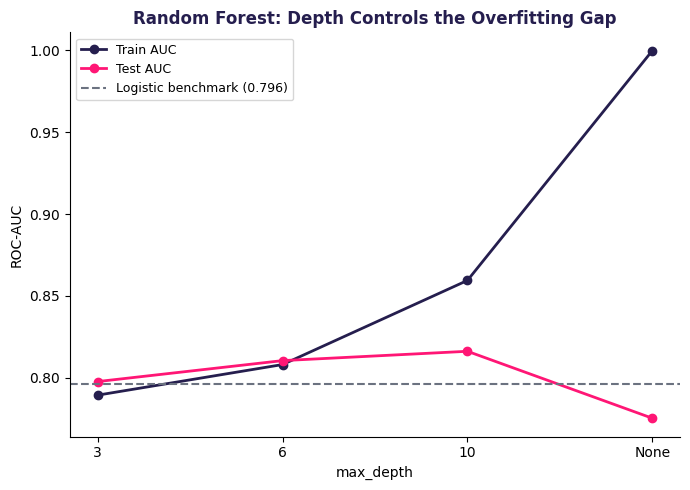

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
depths_x = [3, 6, 10, 20]  # 20 stands in for "unlimited" on the x-axis
labels = ["3", "6", "10", "None"]
train_vals = [r["Train AUC"] for r in depth_rows]
test_vals = [r["Test AUC"] for r in depth_rows]
ax.plot(labels, train_vals, marker="o", color=NAVY, linewidth=2, label="Train AUC")
ax.plot(labels, test_vals, marker="o", color=PINK, linewidth=2, label="Test AUC")
ax.axhline(lr_auc, color=GRAY, linestyle="--", linewidth=1.5, label=f"Logistic benchmark ({lr_auc:.3f})")
ax.set_xlabel("max_depth")
ax.set_ylabel("ROC-AUC")
ax.set_title("Random Forest: Depth Controls the Overfitting Gap", color=NAVY, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**`max_depth=10` is the sweet spot here: test AUC 0.8161, clearing the logistic benchmark by a real margin, with a
much smaller train-test gap (0.043) than the unlimited-depth version (0.225).** This is the same accuracy-trap
instinct from Block 6, one level up: an ensemble's flexibility is a dial, not a free upgrade, and the untuned
default isn't automatically the best-performing setting.


## 4. Second Challenger: Gradient-Boosted Trees

A different strategy — instead of averaging many independent trees, boosting fits trees *sequentially*, each one
correcting the previous ensemble's errors. `HistGradientBoostingClassifier` also regularizes more aggressively out
of the box than a default random forest does.


In [6]:
gbt = HistGradientBoostingClassifier(random_state=42)
gbt.fit(Xtr, ytr)

gbt_train_auc = roc_auc_score(ytr, gbt.predict_proba(Xtr)[:, 1])
gbt_test_auc = roc_auc_score(yte, gbt.predict_proba(Xte)[:, 1])
gbt_pr_auc = average_precision_score(yte, gbt.predict_proba(Xte)[:, 1])
print(f"Gradient boosting (default settings): train AUC = {gbt_train_auc:.4f}, test AUC = {gbt_test_auc:.4f}")
print(f"PR-AUC: {gbt_pr_auc:.4f}")


Gradient boosting (default settings): train AUC = 0.8533, test AUC = 0.8180
PR-AUC: 0.4975


**Gradient boosting beats every other model here, at its default settings, with a small train-test gap (0.035) —
no depth-tuning required.** This is worth noting as its own lesson: boosting's sequential, error-correcting
structure builds in a kind of self-regularization that bagging doesn't get for free.


## 5. The Full Scoreboard


In [7]:
pd.DataFrame({
    "Model": ["Logistic regression (Block 6 benchmark)", "Random Forest (default, unlimited depth)",
              "Random Forest (max_depth=10, tuned)", "Gradient Boosting (default)"],
    "Test ROC-AUC": [lr_auc, rf_test_auc, 0.8161, gbt_test_auc],
}).round(4)


,Model,Test ROC-AUC
0,Logistic regression (Block 6 benchmark),0.7958
1,"Random Forest (default, unlimited depth)",0.7767
2,"Random Forest (max_depth=10, tuned)",0.8161
3,Gradient Boosting (default),0.8180


## 6. What's Driving the Predictions

Random forest feature importances (Gini-based) — a quick, if imperfect, read on what the tuned model leans on.


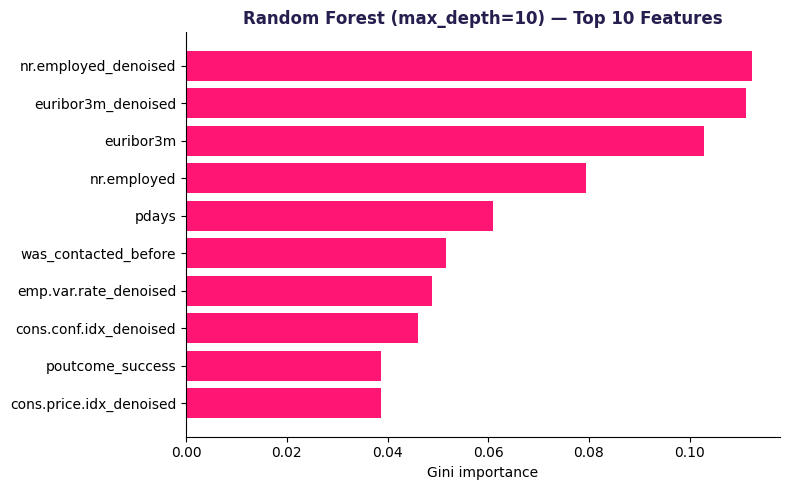

In [8]:
rf_tuned = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_tuned.fit(Xtr, ytr)
importances = pd.Series(rf_tuned.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color=PINK)
ax.set_xlabel("Gini importance")
ax.set_title("Random Forest (max_depth=10) — Top 10 Features", color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


At `max_depth=10`, the macro-economic block leads — `nr.employed_denoised`, `euribor3m_denoised`, `euribor3m`,
`nr.employed`, then `pdays`/`was_contacted_before`. With only 10 splits of depth to work with, the trees spend
their early splits on the strongest, broadest signals (the denoised macro trend) rather than finer-grained
per-client detail — a useful reminder that `max_depth` doesn't just control overfitting, it reshapes which features
the model has room to use at all. Macro conditions and prior-contact history dominating over individual
demographics is also consistent with the campaign-level story: the timing of the call — a market backdrop the bank
can't control — matters more here than most things about the client being called.


## Wrap-Up

- The "more complex model automatically wins" assumption failed its first test today — default Random Forest
  underperformed the simple logistic benchmark by overfitting badly.
- Tuning `max_depth` fixed it: a properly regularized Random Forest (0.8161) and default Gradient Boosting (0.818)
  both clear the benchmark (0.7958) by a real margin.
- **The challenger-model discipline for the MRM audience:** a complex model earns deployment by beating a
  documented, simple benchmark *after* fair tuning — not by being newer or more sophisticated-sounding.

**Next: Block 13** — a hands-on look at *why* bagging reduces variance, building a bagged ensemble from individual
decision trees one piece at a time.
